In [93]:
import pandas as pd

columns = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

columns

['unit_number',
 'time_in_cycles',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
train_file_path = '/content/drive/MyDrive/CMAPSSData/train_FD001.txt'
test_file_path = '/content/drive/MyDrive/CMAPSSData/test_FD001.txt'
ground_truth_file_path = '/content/drive/MyDrive/CMAPSSData/RUL_FD001.txt'

train_df = pd.read_csv(
    train_file_path, 
    sep=r'\s+',       
    header=None,       
    names=columns     
)

test_df = pd.read_csv(
    train_file_path, 
    sep=r'\s+',        
    header=None,      
    names=columns     
)

true_rul = pd.read_csv(
    ground_truth_file_path, 
    sep=r'\s+',       
    header=None,       
    names=['RUL']     
)


In [96]:
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [97]:
test_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [98]:
true_rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [99]:
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max() # max life cycles of each engine
max_cycles

,time_in_cycles
unit_number,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


In [100]:
train_df = train_df.merge(max_cycles.to_frame(name='max_cycles'), left_on='unit_number', right_index=True)
train_df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200


In [ ]:
# Remaining Useful Life = Max Cycles - Current Cycle
train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
train_df = train_df.drop('max_cycles', axis=1)
train_df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [102]:
std_devs = train_df.std()
std_devs



,0
unit_number,2.922763e+01
time_in_cycles,6.888099e+01
op_setting_1,2.187313e-03
op_setting_2,2.930621e-04
op_setting_3,0.000000e+00
sensor_1,6.537152e-11
sensor_2,5.000533e-01
sensor_3,6.131150e+00
sensor_4,9.000605e+00
sensor_5,3.394700e-12


In [103]:
useless_columns = std_devs[std_devs < 0.01].index
useless_columns

Index(['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5',
       'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'],
      dtype='object')

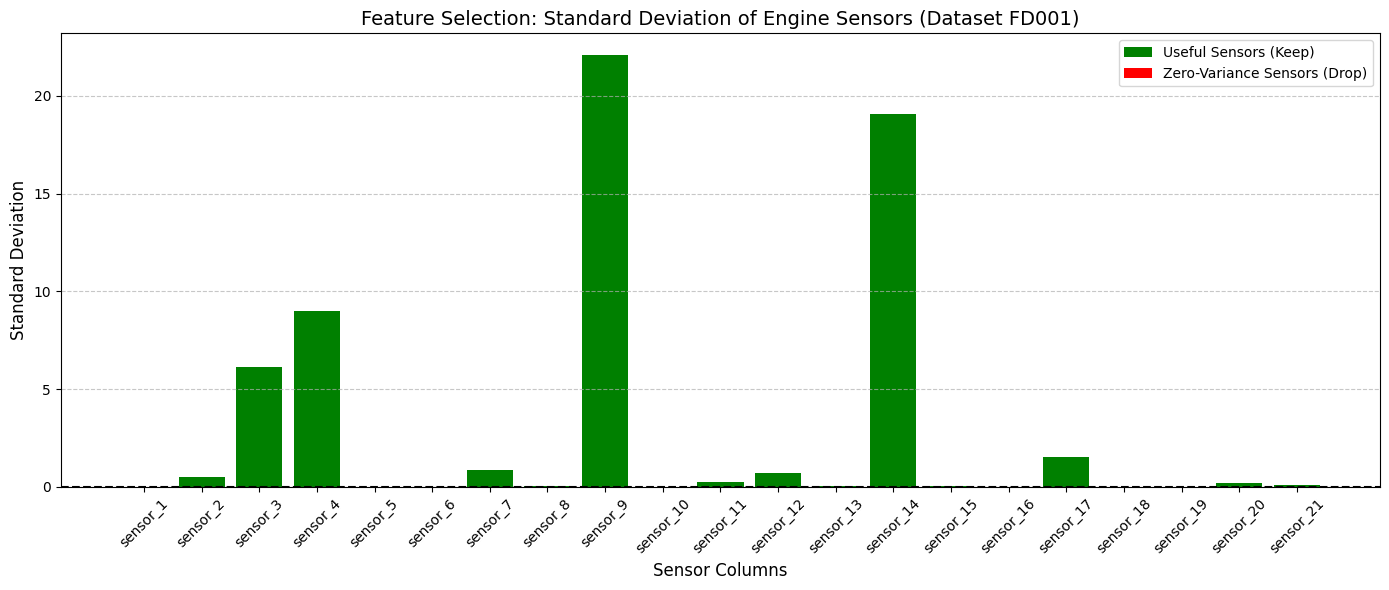

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
sensors_only = train_df[sensor_columns]

std_devs = sensors_only.std()

colors = ['red' if std < 0.01 else 'green' for std in std_devs]

plt.figure(figsize=(14, 6))
bars = plt.bar(std_devs.index, std_devs.values, color=colors)

plt.title('Feature Selection: Standard Deviation of Engine Sensors (Dataset FD001)', fontsize=14)
plt.xlabel('Sensor Columns', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.xticks(rotation=45)

plt.axhline(y=0.01, color='black', linestyle='--', label='Zero-Variance Threshold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Useful Sensors (Keep)'),
                   Patch(facecolor='red', label='Zero-Variance Sensors (Drop)')]
plt.legend(handles=legend_elements)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [105]:
train_df = train_df.drop(useless_columns, axis=1)
test_df = test_df.drop(useless_columns, axis=1)

In [106]:
X_train = train_df.drop(['unit_number', 'time_in_cycles', 'RUL'], axis=1)
y_train = train_df['RUL']

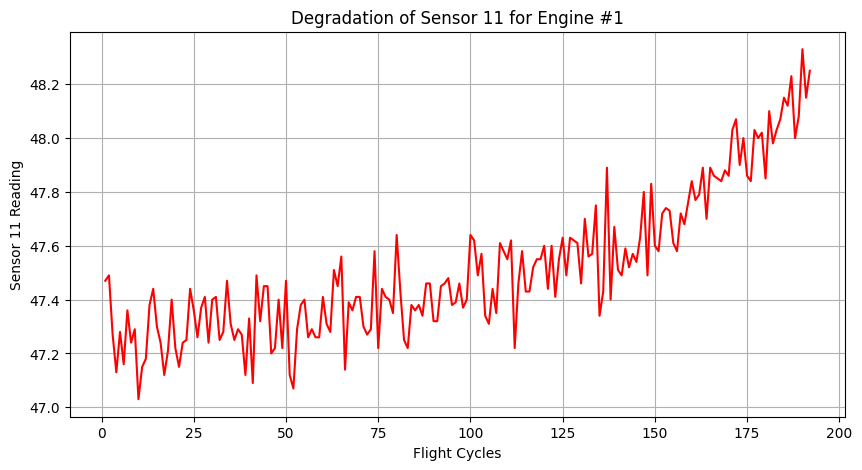

In [107]:
engine_1_data = train_df[train_df['unit_number'] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor_11'], color='red')
plt.title('Degradation of Sensor 11 for Engine #1')
plt.xlabel('Flight Cycles')
plt.ylabel('Sensor 11 Reading')
plt.grid(True)
plt.show()

In [108]:
test_last_cycle = test_df.groupby('unit_number').last().reset_index()
test_last_cycle


,unit_number,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,192,643.54,1601.41,1427.20,551.25,2388.32,9033.22,48.25,520.08,2388.32,8110.93,8.5113,396,38.48,22.9649
1,2,287,643.85,1608.50,1430.84,551.66,2388.20,9109.36,48.12,519.81,2388.21,8175.57,8.5365,398,38.43,23.0848
2,3,179,643.51,1604.80,1428.23,551.91,2388.14,9197.52,48.09,519.53,2388.20,8255.34,8.5056,398,38.40,22.9562
3,4,189,644.53,1612.11,1432.55,551.93,2388.13,9198.32,48.15,519.84,2388.16,8259.42,8.5246,398,38.44,23.1006
4,5,269,643.46,1597.28,1430.74,550.77,2388.18,9157.05,48.26,519.86,2388.16,8212.75,8.5209,397,38.45,23.0296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,336,643.74,1599.20,1432.12,550.78,2388.28,9075.64,48.17,519.18,2388.24,8144.03,8.5022,397,38.36,23.0258
96,97,202,643.79,1610.66,1427.41,551.55,2388.15,9208.02,47.94,519.91,2388.15,8263.63,8.5277,397,38.29,23.1184
97,98,156,643.02,1603.77,1432.16,551.52,2388.24,9058.54,48.29,519.55,2388.26,8122.22,8.5308,396,38.33,23.1137
98,99,185,643.93,1598.42,1421.56,550.64,2388.29,9050.61,48.29,519.99,2388.24,8127.53,8.5425,397,38.49,23.1931


In [ ]:
X_test = test_last_cycle.drop(['unit_number', 'time_in_cycles'], axis=1)
y_test = true_rul['RUL']

In [110]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE (Lower is better): {rmse:.2f} cycles")
    print(f"MAE (Lower is better): {mae:.2f} cycles")
    print(f"R-squared (Closer to 1 is better): {r2:.3f}\n")



In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [113]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_predictions)

--- Linear Regression ---
RMSE (Lower is better): 96.58 cycles
MAE (Lower is better): 85.06 cycles
R-squared (Closer to 1 is better): -4.808



In [114]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_predictions)

--- Random Forest ---
RMSE (Lower is better): 81.81 cycles
MAE (Lower is better): 71.28 cycles
R-squared (Closer to 1 is better): -3.168

